In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/gold_analysis_base.csv")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,playerid,platform,completion_ratio,normalized_score
0,100038,PS,0.760563,0.306481
1,100038,PS,0.657534,0.306481
2,100038,PS,0.196721,0.306481
3,100038,PS,0.261538,0.306481
4,100038,PS,0.037037,0.306481


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nPlatform counts:")
print(df["platform"].value_counts())

df.describe(include="all")

Shape: (1390989, 4)

Columns:
Index(['playerid', 'platform', 'completion_ratio', 'normalized_score'], dtype='object')

Missing values:
playerid                 0
platform                 0
completion_ratio         0
normalized_score    218971
dtype: int64

Platform counts:
platform
XBOX     592234
PS       579784
STEAM    218971
Name: count, dtype: int64


,playerid,platform,completion_ratio,normalized_score
count,1.390989e+06,1390989,1.390989e+06,1.172018e+06
unique,NaN,3,NaN,NaN
top,NaN,XBOX,NaN,NaN
freq,NaN,592234,NaN,NaN
mean,1.205235e+16,NaN,3.074386e-01,1.855306e-01
std,2.788339e+16,NaN,2.697817e-01,1.459486e-01
min,7.700000e+01,NaN,2.000000e-04,1.000000e-02
25%,7.290480e+05,NaN,7.692308e-02,3.950887e-02
50%,1.311048e+06,NaN,2.228571e-01,9.653682e-02
75%,3.949376e+06,NaN,4.835165e-01,3.231175e-01


In [ ]:
df["engagement_score"] = np.where(
    df["platform"] == "STEAM",
    df["completion_ratio"],
    0.6 * df["completion_ratio"] + 0.4 * df["normalized_score"]
)

df.head()

,playerid,platform,completion_ratio,normalized_score,engagement_score
0,100038,PS,0.760563,0.306481,0.578931
1,100038,PS,0.657534,0.306481,0.517113
2,100038,PS,0.196721,0.306481,0.240625
3,100038,PS,0.261538,0.306481,0.279516
4,100038,PS,0.037037,0.306481,0.144815


In [ ]:
summary = df.groupby("platform")[["completion_ratio", "normalized_score", "engagement_score"]].mean()

print(summary)

          completion_ratio  normalized_score  engagement_score
platform                                                      
PS                0.340060          0.331097          0.336475
STEAM             0.274425               NaN          0.274425
XBOX              0.287709          0.043025          0.189835


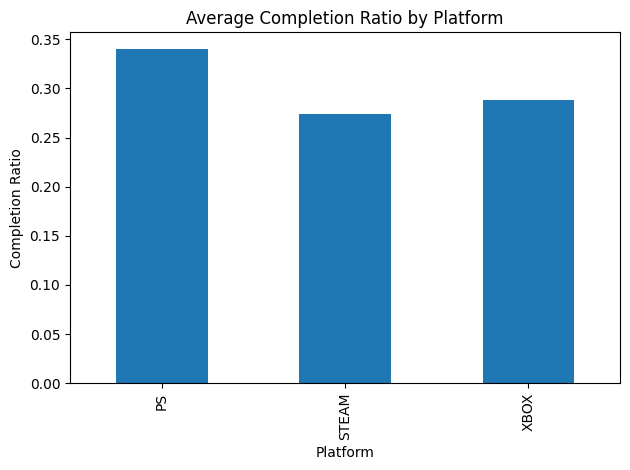

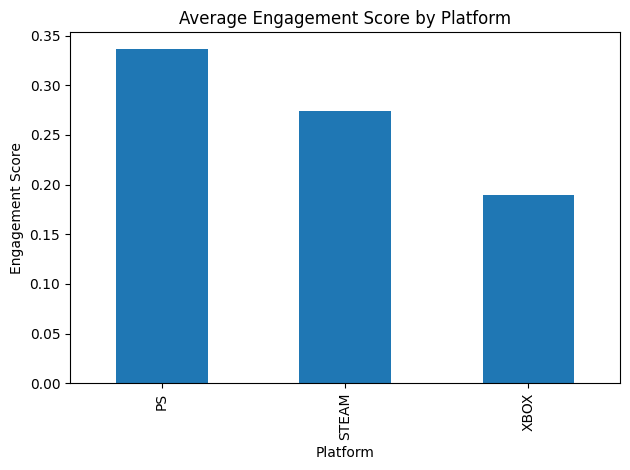

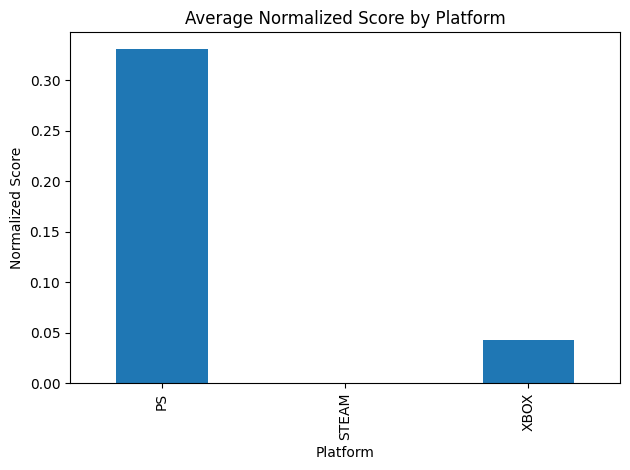

In [ ]:
# Grafik 1: Ortalama completion ratio
summary["completion_ratio"].plot(kind="bar")
plt.title("Average Completion Ratio by Platform")
plt.ylabel("Completion Ratio")
plt.xlabel("Platform")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/avg_completion_by_platform.png")
plt.show()

# Grafik 2: Ortalama engagement score
summary["engagement_score"].plot(kind="bar")
plt.title("Average Engagement Score by Platform")
plt.ylabel("Engagement Score")
plt.xlabel("Platform")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/avg_engagement_by_platform.png")
plt.show()

# Grafik 3: Ortalama normalized score
summary["normalized_score"].plot(kind="bar")
plt.title("Average Normalized Score by Platform")
plt.ylabel("Normalized Score")
plt.xlabel("Platform")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/avg_normalized_score_by_platform.png")
plt.show()